# 02 · Pillar 2 — the measure layer
Build the cosmology-free **MeasurementSet** for every probe. One Universal DataProduct (PointSet / Sightline / FieldMap). Real eBOSS clustering + synthetic for the other probes. **It builds & validates the handoff; it does not compute the estimator.**

In [1]:
%matplotlib inline
import os, sys, tempfile, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, healpy as hp
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / 'test'))
TMP = Path(tempfile.mkdtemp())
DATA_ROOT='/home/ravoux/Documents/Science/Cosmography/oneuniverse_data'
EBOSS=Path(DATA_ROOT)/'spectroscopic/eboss/qso/DR16Q_Superset_v3.fits'
HAVE_EBOSS = EBOSS.exists()
print('real eBOSS data available:', HAVE_EBOSS)

/home/ravoux/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


real eBOSS data available: True


In [2]:
def eboss_or_synth_view(tmp, n_cap=40000):
    from fixtures.measure_ouf import synthetic_point_view
    from oneuniverse.data.converter import write_ouf_dataset
    from oneuniverse.data.dataset_view import DatasetView
    from oneuniverse.data.format_spec import DataGeometry
    from oneuniverse.data.manifest import LoaderSpec
    if not HAVE_EBOSS:
        return synthetic_point_view(tmp, n=n_cap, seed=1, name='synth'), False
    os.environ['ONEUNIVERSE_DATA_ROOT']=DATA_ROOT
    from oneuniverse.data import load_catalog
    df = load_catalog('eboss_qso', validate=False)
    df = df[(df['z']>=0.8)&(df['z']<=2.2)].dropna(subset=['ra','dec','z'])
    if len(df)>n_cap: df=df.sample(n_cap, random_state=0)
    df=df.reset_index(drop=True); n=len(df)
    ra=df['ra'].to_numpy(float); dec=df['dec'].to_numpy(float)
    out=pd.DataFrame({'ra':ra,'dec':dec,'z':df['z'].to_numpy(float),
        'z_type':np.full(n,'spec'),'z_err':np.full(n,1e-4),
        'galaxy_id':np.arange(n,dtype=np.int64),'survey_id':np.zeros(n,dtype=np.int64),
        'weight_comp':np.ones(n),'nbar':np.full(n,1e-3),
        '_original_row_index':np.arange(n,dtype='i8'),
        '_healpix32':hp.ang2pix(32,ra,dec,nest=True,lonlat=True).astype('i4')})
    od=tmp/'eboss'/'oneuniverse'
    write_ouf_dataset(df=out,out_dir=od,survey_name='eboss',survey_type='spectroscopic',
        geometry=DataGeometry.POINT,loader=LoaderSpec(name='eboss',version='0'))
    return DatasetView.from_path(od.parent), True
from oneuniverse.combine.weights import FKPWeight, ColumnWeight
from oneuniverse import measure
print('builders:', [b for b in measure.__all__ if b.startswith('build')])

builders: ['build_galaxy_clustering', 'build_cosmic_shear', 'build_3x2pt', 'build_peculiar_velocity', 'build_sn_hubble', 'build_lya', 'build_map_cross']


## 1 · Galaxy clustering — real eBOSS DR16Q (or synthetic)
Catalog → weights → randoms → n(z) → footprint → region → MeasurementSet.

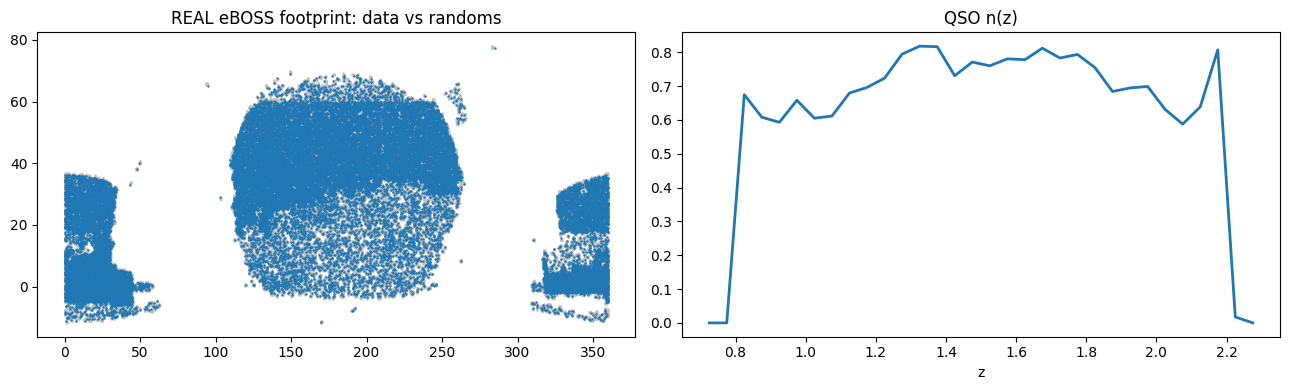

covered fraction: 0.199


In [3]:
view, real = eboss_or_synth_view(TMP, n_cap=40000)
ms = measure.build_galaxy_clustering(view, tracer='qso', z_range=(0.8,2.2),
    weights=[FKPWeight(nbar=lambda z: np.full_like(z,1e-3), P0=1e4)],
    nside_window=64, nside_region=16, nz_edges=np.linspace(0.7,2.3,33),
    randoms='generate', n_randoms=3*view.n_rows, seed=1)
ps=ms.products['qso']; cat,rnd,nz=ps.catalog,ps.randoms,ps.nz
fig,ax=plt.subplots(1,2,figsize=(13,4))
ax[0].scatter(rnd['ra'],rnd['dec'],s=.3,c='.75'); ax[0].scatter(cat['ra'],cat['dec'],s=.5,c='C0')
ax[0].set_title(('REAL eBOSS' if real else 'synthetic')+' footprint: data vs randoms')
ax[1].plot(nz.centers(),nz.pdf(),lw=2); ax[1].set_title('QSO n(z)'); ax[1].set_xlabel('z')
plt.tight_layout(); plt.show()
ms.check_invariants(); print('covered fraction:', round(ps.window.covered_fraction(),3))

## 2 · Weak lensing — shapes + photo-z kernel + tomographic n(z)

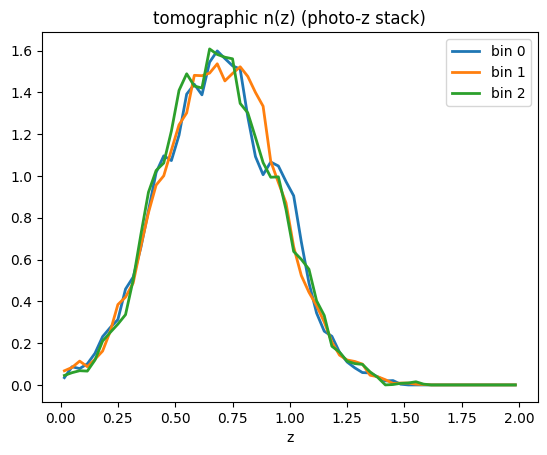

shapes carried: e1,e2,R11,shear_weight; photoz: ProbabilisticRedshift


In [4]:
sv = __import__('fixtures.measure_ouf', fromlist=['synthetic_shear_view']).synthetic_shear_view(TMP, n=5000, seed=3, kind='metacal', with_pdf=True, n_tomo=3, name='src')
ms_wl = measure.build_cosmic_shear(sv, tomo_column='tomo_bin', z_grid=np.linspace(0,2,61), nside_region=8)
wl=ms_wl.products['src']
for b,n in sorted(wl.nz.items()): plt.plot(n.centers(),n.pdf(),lw=2,label=f'bin {b}')
plt.title('tomographic n(z) (photo-z stack)'); plt.xlabel('z'); plt.legend(); plt.show()
print('shapes carried:', wl.attributes if wl.attributes else 'e1,e2,R11,shear_weight; photoz:', type(wl.photoz).__name__)

## 3 · Lyα (Sightline) + 4 · map×catalog (FieldMap)

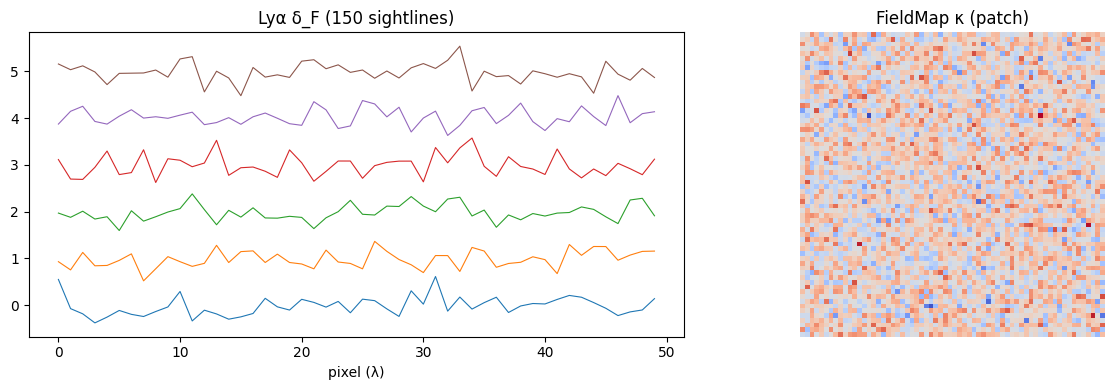

In [5]:
from fixtures.measure_ouf import synthetic_sightline_view, synthetic_healpix_map, synthetic_point_view
from oneuniverse.measure.fieldmap import fieldmap_from_healpix
lya = measure.build_lya(synthetic_sightline_view(TMP, n_los=150, n_pix=50, seed=2, name='lya'), nside_region=8)
vals,mask = synthetic_healpix_map(nside=64, seed=4)
fm = fieldmap_from_healpix(vals, mask=mask, nside=64, dataset_id='cmbk')
xc = measure.build_map_cross(synthetic_point_view(TMP,n=5000,seed=3,name='g2'), fm, nside_region=8, z_range=(0.1,1.0))
fig,ax=plt.subplots(1,2,figsize=(13,4))
sl=lya.products['lya']
for i in range(6): ax[0].plot(sl.delta[i]+i*1.0,lw=.8)
ax[0].set_title(f'Lyα δ_F ({sl.n_sightlines} sightlines)'); ax[0].set_xlabel('pixel (λ)')
ax[1].imshow(fm.values[:4096].reshape(64,64),cmap='coolwarm'); ax[1].set_title('FieldMap κ (patch)'); ax[1].axis('off')
plt.tight_layout(); plt.show()

## All probes, one cosmology-free contract

In [6]:
import json
from fixtures.measure_ouf import synthetic_pv_view, synthetic_sn_view
pv = measure.build_peculiar_velocity(synthetic_pv_view(TMP,n=2000,seed=3,name='pv'), z_range=(0,0.1), nside_region=8)
snv,_ = synthetic_sn_view(TMP,n=300,seed=4,name='sn'); sn=measure.build_sn_hubble(snv, nside_region=4)
rows=[('clustering',ms),('cosmic_shear',ms_wl),('pec_velocity',pv),('sn',sn),('lya',lya),('map_cross',xc)]
print(f"{'probe':14s} {'family':12s} {'statistic':14s} subtypes")
for nm,m in rows:
    s=m.summary(); kinds=','.join(p['kind'] for p in s['products'].values())
    print(f"{nm:14s} {s['spec']['estimator_family']:12s} {s['spec']['statistic']:14s} {kinds}")
json.dumps(ms.summary()); print('\nsummary() is JSON-serialisable + cosmology_free =', ms.summary()['cosmology_free'])

probe          family       statistic      subtypes
clustering     clustering   pk_multipole   pointset
cosmic_shear   lensing      xi_pm          pointset
pec_velocity   velocity     velocity_correlation pointset
sn             sn           hubble         pointset
lya            lya          p1d            sightline
map_cross      cross        cl             pointset,fieldmap

summary() is JSON-serialisable + cosmology_free = True


**Recap.** Six builders, three subtypes, one cosmology-free output. The container also expresses clusters / strong-lens time-delays / radio z-absent / GW sirens / LIM via optional atom slots (see `test_measure_generality.py`).